# Complex CNN - BatchNorm, seed 42

Selected Model 2: a Sequential-Parallel CNN with two MBConv blocks.
Restart the kernel and run cells in order.
Use the shared patient split and preprocessing; augment the training split only.
Each execution creates a separate folder under `runs/`, using `complex_cnn_*` artifact names.
The selected training run's checkpoint and reports are preserved in the project's `models/` and `reports/` folders.


## 1. Environment and shared modules


In [1]:
import os
import torch

os.environ["KERAS_BACKEND"] = "torch"
DEVICE = "cpu"
PRECISION = "float32"
os.environ["KERAS_TORCH_DEVICE"] = DEVICE


In [2]:
DEVICE = "cuda"
PRECISION = "mixed_float16"
os.environ["KERAS_TORCH_DEVICE"] = DEVICE
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False


### Import shared modules


In [3]:
from pathlib import Path
from datetime import datetime
import sys
import numpy as np
import pandas as pd

import tensorflow as tf
import keras
from IPython.display import display, Image

PROJECT_DIR = next(path for path in (
    Path.cwd(), Path.cwd() / "new_project",
    Path.cwd() / "multi-class-brain-tumor-classification/new_project", *Path.cwd().parents,
) if (path / "src/data_loader.py").is_file())
sys.path.insert(0, str(PROJECT_DIR))
from src.train_complex_cnn import train_model
from src.data_loader import build_tf_dataset
from src.preprocessing import load_split_manifest
from src.evaluation import collect_predictions, compute_metrics, evaluate_model, save_json, plot_confusion_matrix



## 2. Configuration and output paths

Physical batch size 8, gradient accumulation 4 (effective batch size 32). Adam without weight decay.
Cosine decay uses `train_batches * 60` steps, matching the original run, with a minimum LR of 1e-6.
Early stopping monitors `val_loss`, starts at `start_from_epoch=60`, and uses patience 20.
The checkpoint is selected by the lowest validation loss across the entire training run.


In [4]:
SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 8
ACCUMULATION_STEPS = 4
EPOCHS = 90
DECAY_EPOCHS = 60
LEARNING_RATE = 2e-4
MIN_LEARNING_RATE = 1e-6
BN_MOMENTUM = 0.9
BN_EPSILON = 1e-3
DROPOUT_RATE = 0.2
PATIENCE = 20
MIN_DELTA = 0.0

keras.utils.set_random_seed(SEED)
tf.random.set_seed(SEED)
keras.mixed_precision.set_global_policy(PRECISION)
torch.set_num_threads(8)

MODEL_NAME = "complex_cnn"
RUN_DIR = PROJECT_DIR / "runs" / f"complex_cnn_seed42_{datetime.now():%Y%m%d_%H%M%S_%f}"
REPORTS_DIR = RUN_DIR / "reports"
CHECKPOINT_PATH = RUN_DIR / "models" / f"{MODEL_NAME}_best.keras"
REPORTS_DIR.mkdir(parents=True, exist_ok=False)
CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=False)
print("Results:", RUN_DIR)


Results: c:\Users\ADMIN\Documents\Ky7\DL\multi-class-brain-tumor-classification\new_project\runs\complex_cnn_seed42_20261010_203050_660647


## 3. Training and validation data


In [5]:
manifest = load_split_manifest(PROJECT_DIR / "data/processed/split_manifest.csv")
RAW_DIR = PROJECT_DIR / "data/raw"
split_counts = manifest.groupby(["split", "class_name"]).size().unstack(fill_value=0)
display(split_counts)

train_dataset = build_tf_dataset(
    manifest, RAW_DIR, split="train", image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE, training=True, seed=SEED,
)
validation_dataset = build_tf_dataset(
    manifest, RAW_DIR, split="validation", image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)
train_batches = int(np.ceil(manifest["split"].eq("train").sum() / BATCH_SIZE))
validation_batches = int(np.ceil(manifest["split"].eq("validation").sum() / BATCH_SIZE))
train_dataset = train_dataset.apply(tf.data.experimental.assert_cardinality(train_batches))
validation_dataset = validation_dataset.apply(tf.data.experimental.assert_cardinality(validation_batches))

manifest.to_csv(REPORTS_DIR / "split_manifest_used.csv", index=False)


class_name,glioma,meningioma,pituitary tumor
split,,,
test,228,114,159
train,968,485,618
validation,230,109,153


## 4. Model architecture

| Component | Operations | Output at input 224x224 |
|---|---|---|
| Sequential branch | Conv3x3(32), Conv3x3(64), Pool2, Conv3x3(128), Pool2 | 56x56x128 |
| Parallel branch | Conv1x1 / Conv3x3 / Conv5x5, 16 channels each; concatenate; Pool2; Pool2 | 56x56x48 |
| Fusion | Concatenate; Conv3x3(128), BN, ReLU | 56x56x128 |
| MBConv x2 | Conv1x1(256), BN, ReLU6; depthwise3x3, BN, ReLU6; Conv1x1(128), BN; residual Add | 56x56x128 |
| Classifier | GAP; Dense128 ReLU; Dropout; Dense3 softmax | 3 classes |

Each MBConv has expansion ratio 2 and stride 1. Projection and residual addition have no following activation. Other convolution blocks use BN and ReLU. The default model has 456,755 parameters.

BN uses momentum 0.9 and epsilon 1e-3 throughout.

The same model definition is available in `src/complex_cnn.py` for comparison scripts.


In [6]:
layers = keras.layers

def mbconv_block(x, name, bn_momentum=0.9, norm_epsilon=1e-3):
    """128 -> 256 -> 128 channels, depthwise3x3, linear projection, shortcut."""
    shortcut = x
    r = layers.Conv2D(256, 1, padding="same", use_bias=False,
                    name=f"{name}_expand")(x)
    r = layers.BatchNormalization(momentum=bn_momentum, epsilon=norm_epsilon, name=f"{name}_expand_bn")(r)
    r = layers.ReLU(max_value=6, name=f"{name}_expand_relu6")(r)
    r = layers.DepthwiseConv2D(3, padding="same", use_bias=False,
                            name=f"{name}_depthwise")(r)
    r = layers.BatchNormalization(momentum=bn_momentum, epsilon=norm_epsilon, name=f"{name}_depthwise_bn")(r)
    r = layers.ReLU(max_value=6, name=f"{name}_depthwise_relu6")(r)
    r = layers.Conv2D(128, 1, padding="same", use_bias=False,
                    name=f"{name}_project")(r)
    r = layers.BatchNormalization(momentum=bn_momentum, epsilon=norm_epsilon, name=f"{name}_project_bn")(r)
    return layers.Add(name=f"{name}_add")([shortcut, r])

def build_complex_cnn(decay_steps, learning_rate=2e-4, min_learning_rate=1e-6,
                    image_size=224, bn_momentum=0.9, dropout_rate=0.2,
                    accumulation_steps=4, norm_epsilon=1e-3):
    """Build and compile the two-branch CNN in one function."""
    inputs = keras.Input(shape=(image_size, image_size, 3), name="input_image")

    sequential = layers.Conv2D(32, 3, padding="same", use_bias=False, name="seq1_conv")(inputs)
    sequential = layers.BatchNormalization(momentum=bn_momentum, epsilon=norm_epsilon, name="seq1_bn")(sequential)
    sequential = layers.Activation("relu", name="seq1_relu")(sequential)

    sequential = layers.Conv2D(64, 3, padding="same", use_bias=False, name="seq2_conv")(sequential)
    sequential = layers.BatchNormalization(momentum=bn_momentum, epsilon=norm_epsilon, name="seq2_bn")(sequential)
    sequential = layers.Activation("relu", name="seq2_relu")(sequential)
    sequential = layers.MaxPooling2D(2, name="seq2_pool")(sequential)

    sequential = layers.Conv2D(128, 3, padding="same", use_bias=False, name="seq3_conv")(sequential)
    sequential = layers.BatchNormalization(momentum=bn_momentum, epsilon=norm_epsilon, name="seq3_bn")(sequential)
    sequential = layers.Activation("relu", name="seq3_relu")(sequential)
    sequential = layers.MaxPooling2D(2, name="seq3_pool")(sequential)
    # The parallel branch uses three different kernel sizes to capture multi-scale features.
    branches = []
    for kernel_size in (1, 3, 5):
        branch = layers.Conv2D(16, kernel_size, padding="same", use_bias=False,
                        name=f"par_{kernel_size}x{kernel_size}_conv")(inputs)
        branch = layers.BatchNormalization(momentum=bn_momentum, epsilon=norm_epsilon, name=f"par_{kernel_size}x{kernel_size}_bn")(branch)
        branch = layers.Activation("relu", name=f"par_{kernel_size}x{kernel_size}_relu")(branch)
        branches.append(branch)

    parallel = layers.Concatenate(name="par_concat")(branches)
    parallel = layers.MaxPooling2D(2, name="par_pool1")(parallel)
    parallel = layers.MaxPooling2D(2, name="par_pool")(parallel)

    x = layers.Concatenate(name="merge_concat")([sequential, parallel])
    x = layers.Conv2D(128, 3, padding="same", use_bias=False, name="fusion_conv")(x)
    x = layers.BatchNormalization(momentum=bn_momentum, epsilon=norm_epsilon, name="fusion_bn")(x)
    x = layers.Activation("relu", name="fusion_relu")(x)

    x = mbconv_block(x, name="mb1", bn_momentum=bn_momentum, norm_epsilon=norm_epsilon)
    x = mbconv_block(x, name="mb2", bn_momentum=bn_momentum, norm_epsilon=norm_epsilon)

    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dense(128, activation="relu", name="dense_128")(x)
    x = layers.Dropout(dropout_rate, name="dropout")(x)
    outputs = layers.Dense(3, activation="softmax", name="predictions", dtype="float32")(x)
    model = keras.Model(inputs, outputs, name="complex_sequential_parallel_batchnorm_cnn")

    lr_schedule = keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=learning_rate,
        decay_steps=decay_steps,
        alpha=min_learning_rate / learning_rate,
    )
    model.compile(optimizer=keras.optimizers.Adam(
                    learning_rate=lr_schedule,
                    gradient_accumulation_steps=accumulation_steps,
                ),
                loss="categorical_crossentropy", metrics=["accuracy"])
    return model


## 5. Model initialization and summary


In [7]:
model = build_complex_cnn(
    decay_steps=train_batches * DECAY_EPOCHS,
    learning_rate=LEARNING_RATE, min_learning_rate=MIN_LEARNING_RATE,
    image_size=IMAGE_SIZE, bn_momentum=BN_MOMENTUM, norm_epsilon=BN_EPSILON,
    dropout_rate=DROPOUT_RATE, accumulation_steps=ACCUMULATION_STEPS,
)
summary_lines = []
model.summary(print_fn=summary_lines.append)
(REPORTS_DIR / f"{MODEL_NAME}_summary.txt").write_text("\n".join(summary_lines), encoding="utf-8")


11788

## 6. Training and checkpoint selection


In [8]:
callbacks = [
    keras.callbacks.TerminateOnNaN(),
    keras.callbacks.CSVLogger(str(REPORTS_DIR / "training_log.csv")),
    keras.callbacks.ModelCheckpoint(
        str(CHECKPOINT_PATH), monitor="val_loss", mode="min", save_best_only=True,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss", mode="min", patience=PATIENCE, min_delta=MIN_DELTA,
        start_from_epoch=DECAY_EPOCHS, restore_best_weights=False,
    ),
]
history = train_model(
    model, train_dataset, validation_dataset, CHECKPOINT_PATH, REPORTS_DIR,
    MODEL_NAME, callbacks=callbacks, epochs=EPOCHS,
)
best_epoch = int(np.argmin(history["val_loss"])) + 1


Epoch 1/90
259/259 - 50s - 192ms/step - accuracy: 0.6210 - loss: 0.8166 - val_accuracy: 0.6728 - val_loss: 0.6562
Epoch 2/90
259/259 - 45s - 173ms/step - accuracy: 0.7253 - loss: 0.6450 - val_accuracy: 0.7195 - val_loss: 0.5981
Epoch 3/90
259/259 - 45s - 173ms/step - accuracy: 0.7740 - loss: 0.5482 - val_accuracy: 0.8333 - val_loss: 0.3851
Epoch 4/90
259/259 - 45s - 173ms/step - accuracy: 0.7933 - loss: 0.5141 - val_accuracy: 0.7073 - val_loss: 0.8245
Epoch 5/90
259/259 - 45s - 172ms/step - accuracy: 0.7914 - loss: 0.4920 - val_accuracy: 0.7866 - val_loss: 0.4423
Epoch 6/90
259/259 - 44s - 171ms/step - accuracy: 0.8059 - loss: 0.4616 - val_accuracy: 0.7764 - val_loss: 0.4298
Epoch 7/90
259/259 - 46s - 176ms/step - accuracy: 0.8228 - loss: 0.4254 - val_accuracy: 0.7764 - val_loss: 0.5939
Epoch 8/90
259/259 - 46s - 177ms/step - accuracy: 0.8276 - loss: 0.4087 - val_accuracy: 0.8435 - val_loss: 0.3365
Epoch 9/90
259/259 - 46s - 177ms/step - accuracy: 0.8527 - loss: 0.3679 - val_accuracy: 

## 7. Learning curve


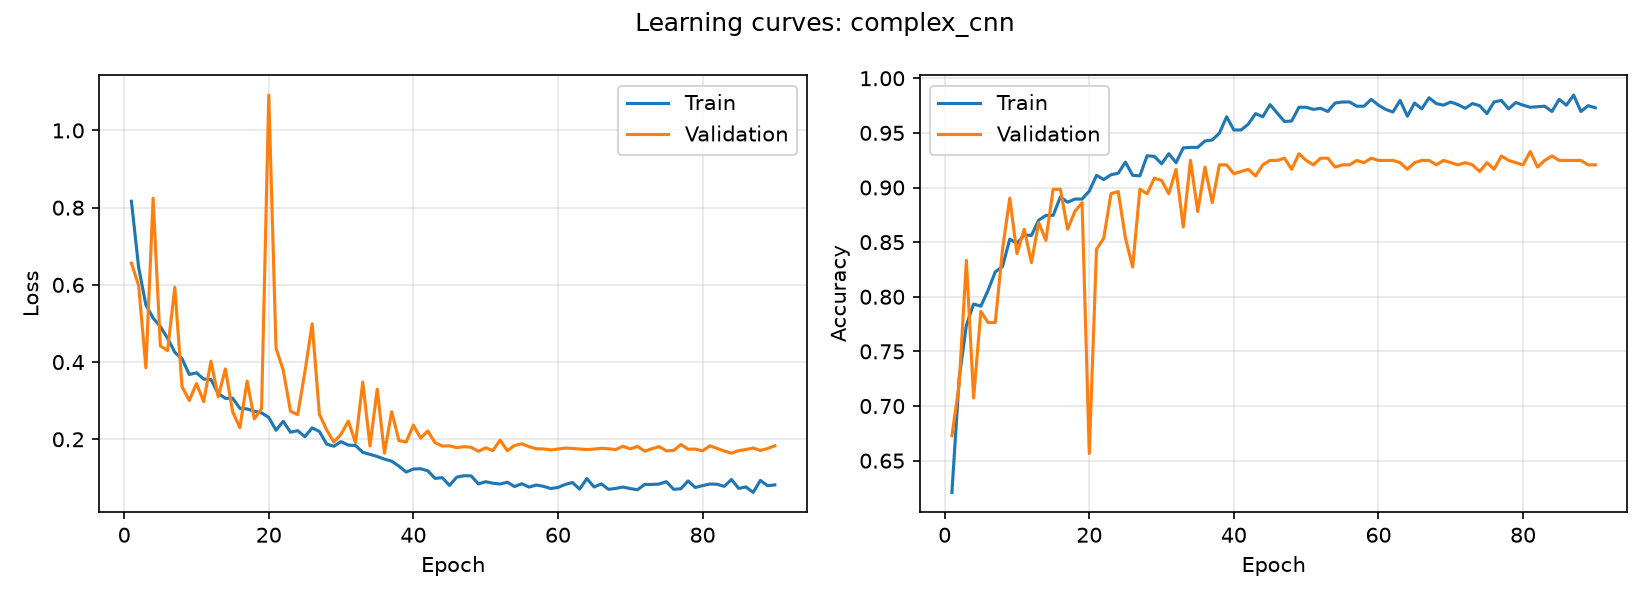

Epoch with the lowest validation loss: 84


In [9]:
display(Image(filename=str(REPORTS_DIR / f"{MODEL_NAME}_learning_curve.png")))
print("Epoch with the lowest validation loss:", best_epoch)


## 8. Validation evaluation using the best checkpoint


,validation
loss,0.164010
accuracy,0.928862
macro_precision,0.920489
macro_recall,0.925443
macro_f1,0.922849


,precision,recall,f1,support
glioma,0.938053,0.921739,0.929825,230.0
meningioma,0.849558,0.880734,0.864865,109.0
pituitary tumor,0.973856,0.973856,0.973856,153.0


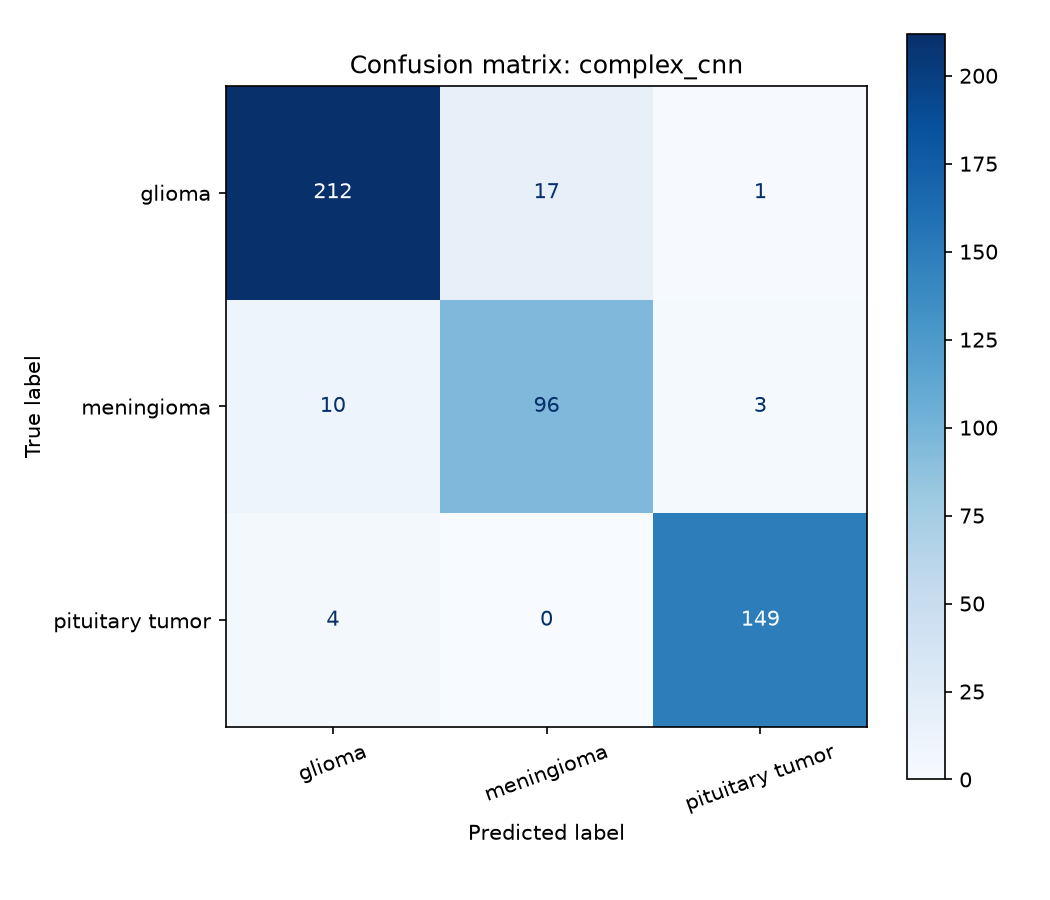

In [10]:
best_model = keras.models.load_model(CHECKPOINT_PATH)
validation_metrics = {
    key: float(value) for key, value in
    best_model.evaluate(validation_dataset, return_dict=True, verbose=0).items()
}
y_true, y_prob, _ = collect_predictions(best_model, validation_dataset)
validation_metrics.update(compute_metrics(y_true, y_prob))
validation_metrics.update(split="validation", num_validation_images=len(y_true))
save_json(validation_metrics, REPORTS_DIR / f"{MODEL_NAME}_validation_metrics.json")
plot_confusion_matrix(validation_metrics["confusion_matrix"],
                    REPORTS_DIR / f"{MODEL_NAME}_validation_confusion_matrix.png", MODEL_NAME)
display(pd.Series({key: validation_metrics[key] for key in
                ["loss", "accuracy", "macro_precision", "macro_recall", "macro_f1"]}).to_frame("validation"))
display(pd.DataFrame(validation_metrics["per_class_metrics"]).T)
display(Image(filename=str(REPORTS_DIR / f"{MODEL_NAME}_validation_confusion_matrix.png")))


## 9. Test evaluation

Evaluate only after selecting the checkpoint by validation loss.
The test cohort was inspected in earlier experiments, so this remains an exploratory comparison.
The shared evaluation module reports classification metrics, parameter count, and inference time (ms/image).


,test
accuracy,0.852295
macro_precision,0.825662
macro_recall,0.821831
macro_f1,0.817615


,precision,recall,f1,support
glioma,0.971292,0.890351,0.929062,228.0
meningioma,0.712766,0.587719,0.644231,114.0
pituitary tumor,0.792929,0.987421,0.879552,159.0


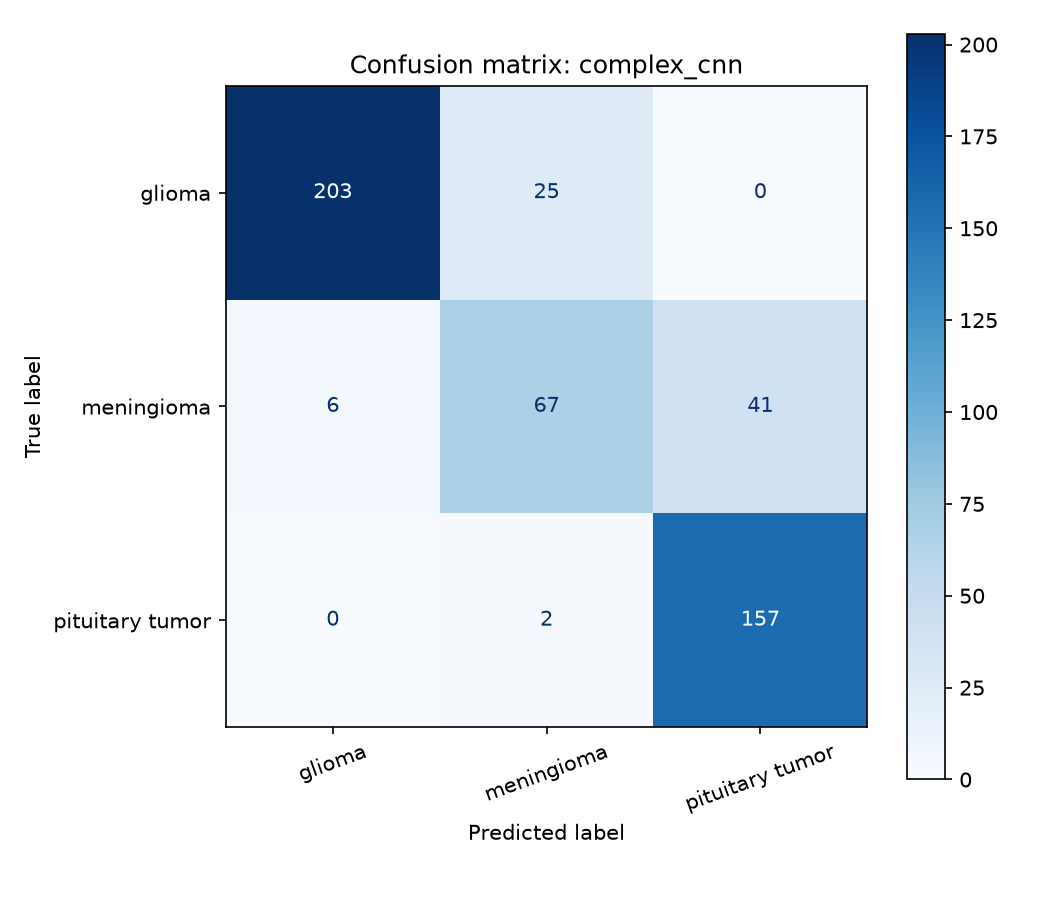

In [11]:
test_dataset = build_tf_dataset(
    manifest, RAW_DIR, split="test", image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
)
test_metrics = evaluate_model(best_model, test_dataset, MODEL_NAME, reports_dir=REPORTS_DIR)
display(pd.Series({key: test_metrics[key] for key in
                ["accuracy", "macro_precision", "macro_recall", "macro_f1"]}).to_frame("test"))
display(pd.DataFrame(test_metrics["per_class_metrics"]).T)
display(Image(filename=str(REPORTS_DIR / f"{MODEL_NAME}_confusion_matrix.png")))
